In [1]:
import numpy as np 
import xarray as xr 
import matplotlib.pyplot as plt
from util import *

%load_ext autoreload    
%autoreload 2

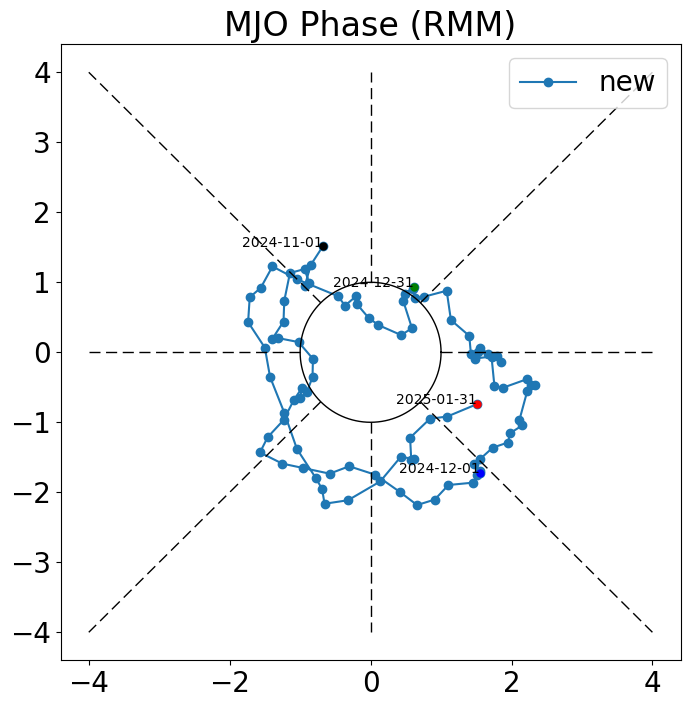

In [7]:
from util import mjo_phase_background

datesta = '2024-11-01'
dateend = '2025-01-31'

ds = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/rmm/RMM_ERA5_daily_1979to2001.nc')
# ds = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/rmm/RMM_ERA5_daily_1980to2001.noaa.nc')
RMM_new = ds['RMM'].sel(time=slice(datesta,dateend))
pc1 = RMM_new[:,0]
pc2 = RMM_new[:,1]
time = RMM_new['time']
ntim = len(time)

plMark = dict(markersize=5)
plLine = dict(linewidth=1.0)
txres = dict(fontsize=10)

# Convert the time column to datetime format
import pandas as pd 
time = pd.to_datetime(time)


# Define a colormap for the months
cmap = plt.cm.get_cmap('tab10')
plt.rcParams.update({'font.size': 20})
# Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title(f"MJO Phase (RMM)")

ax.plot(pc1, pc2, 'o-', label='new')
# Mark the first and last points
ax.plot(pc1[0], pc2[0], 'o', color="black", **plMark)
ax.plot(pc1[30], pc2[30], 'o', color="blue", **plMark)
ax.plot(pc1[60], pc2[60], 'o', color="green", **plMark)
ax.plot(pc1[-1], pc2[-1], 'o', color="red", **plMark)

ax.legend()

# add text to the points every 10 days
ax.text(pc1[0], pc2[0], time[0].strftime('%Y-%m-%d'), ha='right', **txres)
ax.text(pc1[30], pc2[30], time[30].strftime('%Y-%m-%d'), ha='right', **txres)
ax.text(pc1[60], pc2[60], time[60].strftime('%Y-%m-%d'), ha='right', **txres)
ax.text(pc1[-1], pc2[-1], time[-1].strftime('%Y-%m-%d'), ha='right', **txres)


mjo_phase_background(ax)

lim = 3
plt.show()

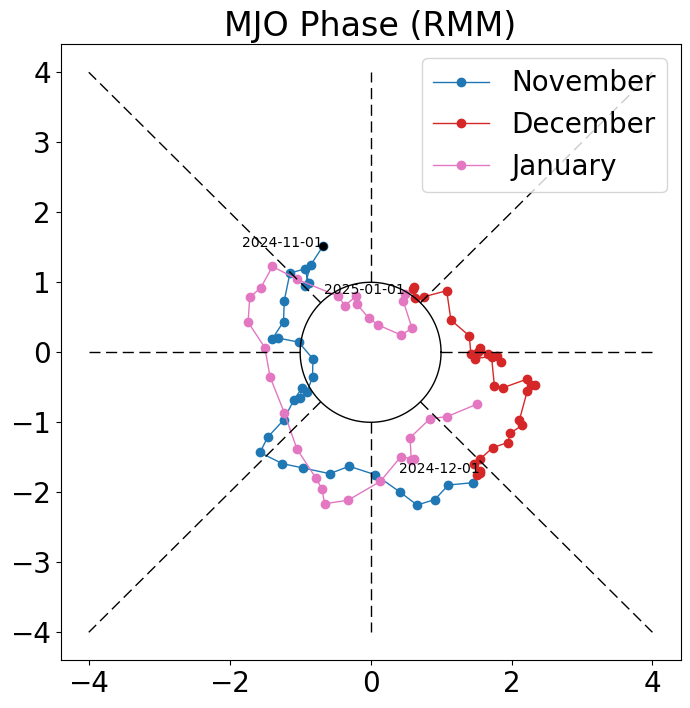

In [9]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar
from util import mjo_phase_background

# Define start and end dates
datesta = '2024-11-01'
dateend = '2025-01-31'

# Open the dataset and extract the relevant portion
ds = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/rmm/RMM_ERA5_daily_1979to2001.nc')
RMM_new = ds['RMM'].sel(time=slice(datesta, dateend))
pc1 = RMM_new[:, 0].values  # Convert to numpy array for easier indexing
pc2 = RMM_new[:, 1].values
time = pd.to_datetime(RMM_new['time'].values)

# Plot style parameters
plMark = dict(markersize=5)
plLine = dict(linewidth=1.0)
txres = dict(fontsize=10)

# Use the 'tab10' colormap for distinct colors
cmap = plt.cm.get_cmap('tab10')

plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title("MJO Phase (RMM)")

# Create a list of unique months in the order they appear in the dataset
unique_months = []
for t in time:
    if t.month not in unique_months:
        unique_months.append(t.month)

nmonths = len(unique_months)
# Build a color mapping: each unique month gets a different color from the colormap
colors = {m: cmap(i / nmonths) for i, m in enumerate(unique_months)}

# Plot data by month
for m in unique_months:
    # Get indices corresponding to the current month
    idx = (time.month == m)
    # Label the plot with the full month name (e.g., "November")
    label = calendar.month_name[m]
    ax.plot(pc1[idx], pc2[idx], 'o-', label=label, color=colors[m], **plLine)
    # Optionally add text at the first point of the month
    first_idx = np.where(idx)[0][0]
    ax.text(pc1[first_idx], pc2[first_idx], time[first_idx].strftime('%Y-%m-%d'),
            ha='right', **txres)

# Mark the very first and last points of the dataset with distinct markers
ax.plot(pc1[0], pc2[0], 'o', color="black", **plMark)
# ax.plot(pc1[-1], pc2[-1], 'o', color="red", **plMark)

ax.legend()

# Add the MJO phase background for context
mjo_phase_background(ax)

plt.show()


In [ ]:
fn = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/targets/ROMI_ERA5_daily_1979to2012.nc'

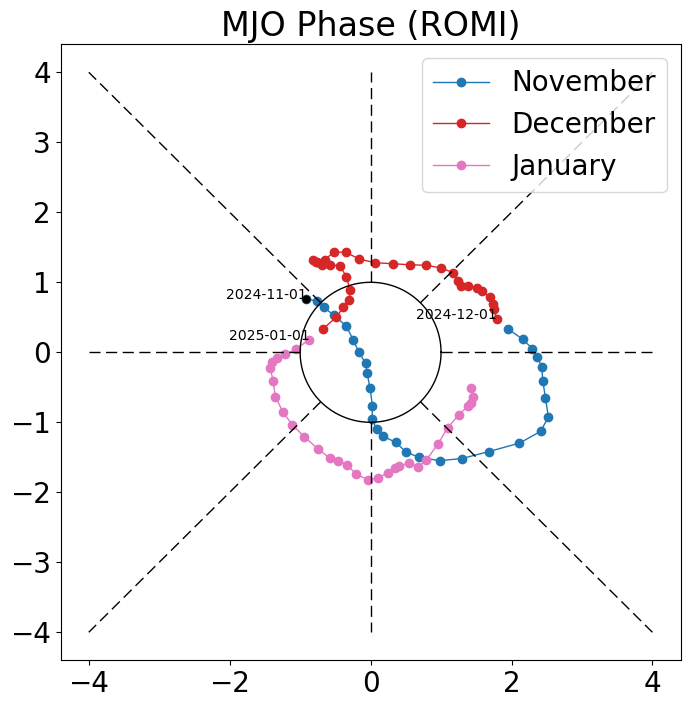

In [11]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar
from util import mjo_phase_background

# Define start and end dates
datesta = '2024-11-01'
dateend = '2025-01-31'

# Open the dataset and extract the relevant portion
ds = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/targets/ROMI_ERA5_daily_1979to2012.nc')
RMM_new = ds['ROMI'].sel(time=slice(datesta, dateend))
pc1 = RMM_new[:, 1].values  # Convert to numpy array for easier indexing
pc2 = -RMM_new[:, 0].values
time = pd.to_datetime(RMM_new['time'].values)

# Plot style parameters
plMark = dict(markersize=5)
plLine = dict(linewidth=1.0)
txres = dict(fontsize=10)

# Use the 'tab10' colormap for distinct colors
cmap = plt.cm.get_cmap('tab10')

plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title("MJO Phase (ROMI)")

# Create a list of unique months in the order they appear in the dataset
unique_months = []
for t in time:
    if t.month not in unique_months:
        unique_months.append(t.month)

nmonths = len(unique_months)
# Build a color mapping: each unique month gets a different color from the colormap
colors = {m: cmap(i / nmonths) for i, m in enumerate(unique_months)}

# Plot data by month
for m in unique_months:
    # Get indices corresponding to the current month
    idx = (time.month == m)
    # Label the plot with the full month name (e.g., "November")
    label = calendar.month_name[m]
    ax.plot(pc1[idx], pc2[idx], 'o-', label=label, color=colors[m], **plLine)
    # Optionally add text at the first point of the month
    first_idx = np.where(idx)[0][0]
    ax.text(pc1[first_idx], pc2[first_idx], time[first_idx].strftime('%Y-%m-%d'),
            ha='right', **txres)

# Mark the very first and last points of the dataset with distinct markers
ax.plot(pc1[0], pc2[0], 'o', color="black", **plMark)
# ax.plot(pc1[-1], pc2[-1], 'o', color="red", **plMark)

ax.legend()

# Add the MJO phase background for context
mjo_phase_background(ax)

plt.show()


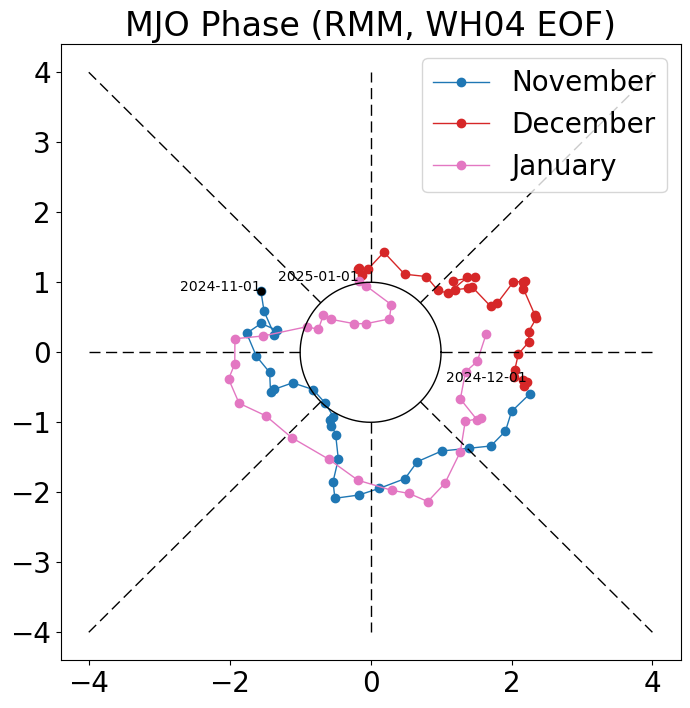

In [13]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar
from util import mjo_phase_background

# Define start and end dates
datesta = '2024-11-01'
dateend = '2025-01-31'

# Open the dataset and extract the relevant portion
ds = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/rmm/RMM_ERA5_daily_1979to2001WH04EOF.nc')
RMM_new = ds['RMM'].sel(time=slice(datesta, dateend))
pc1 = RMM_new[:, 0].values  # Convert to numpy array for easier indexing
pc2 = RMM_new[:, 1].values
time = pd.to_datetime(RMM_new['time'].values)

# Plot style parameters
plMark = dict(markersize=5)
plLine = dict(linewidth=1.0)
txres = dict(fontsize=10)

# Use the 'tab10' colormap for distinct colors
cmap = plt.cm.get_cmap('tab10')

plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title("MJO Phase (RMM, WH04 EOF)")

# Create a list of unique months in the order they appear in the dataset
unique_months = []
for t in time:
    if t.month not in unique_months:
        unique_months.append(t.month)

nmonths = len(unique_months)
# Build a color mapping: each unique month gets a different color from the colormap
colors = {m: cmap(i / nmonths) for i, m in enumerate(unique_months)}

# Plot data by month
for m in unique_months:
    # Get indices corresponding to the current month
    idx = (time.month == m)
    # Label the plot with the full month name (e.g., "November")
    label = calendar.month_name[m]
    ax.plot(pc1[idx], pc2[idx], 'o-', label=label, color=colors[m], **plLine)
    # Optionally add text at the first point of the month
    first_idx = np.where(idx)[0][0]
    ax.text(pc1[first_idx], pc2[first_idx], time[first_idx].strftime('%Y-%m-%d'),
            ha='right', **txres)

# Mark the very first and last points of the dataset with distinct markers
ax.plot(pc1[0], pc2[0], 'o', color="black", **plMark)
# ax.plot(pc1[-1], pc2[-1], 'o', color="red", **plMark)

ax.legend()

# Add the MJO phase background for context
mjo_phase_background(ax)

plt.show()
